.<center> 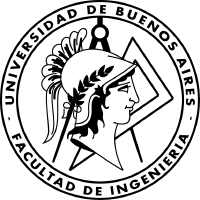



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP7: Aprendizaje No Supervisado**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Creación del Dataset

### (a.1)

Creamos un conjunto de datos $\{X_i\}^{200}_{i=1}$ no supervisado de tamaño 200 y dimensión 2. Definimos a $X_i$ como:

$$X_i = g(U_i)+0.05\cdot Z_i$$

En donde, $U_i\sim\mathcal{U}(0,1)$, los $Z_i$ son vectores aleatorios i.i.d normal estándar bivariados y la función $g:\mathbb{R}\to\mathbb{R}^2$ es definida como:

$$g(u)=\begin{cases}
(0;4u) & 0\leq u < 0.25\\
(2u-0.5;1.5-2u)& 0.25\leq u < 0.5\\
(2u-0.5;2u-0.5)& 0.5 \leq u < 0.75\\
(1;4-4u)&  0.7\leq u \leq 1
\end{cases}$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n=200
U=np.random.uniform(0,1,n)
Z=np.random.rand(2,n)

def g(u):
  if u < 0.25:
    return np.array([0, 4*u])
  if u < 0.5:
    return np.array([2*u-0.5, 1.5-2*u])
  if u < 0.75:
    return np.array([2*u-0.5, 2*u-0.5])
  if u <= 1:
    return np.array([1, 4-4*u])

X = np.array([g(u) + 0.05*Z[:,i] for i, u in enumerate(U)])

### (a.2)

Se realiza un gráfico de dispersión del conjunto de datos y se observa que tienen la forma de la letra M.

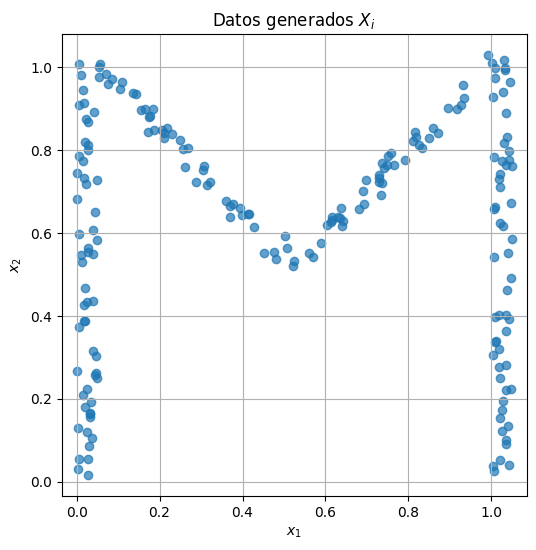

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], alpha=0.7)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Datos generados $X_i$")
plt.axis("equal")
plt.grid()
plt.show()

### (a.3)

En este gráfico se representa la curva del manifold $𝑀$, que es el conjunto de puntos generados por la función $g(u)$ para valores de $𝑢$ entre 0 y 1. Esta curva se define como:

$$M=\{g(u)\in\mathbb{R}^2:0<u<1\}$$

Esta curva puede interpretarse como el modelo teórico o función generadora de los datos, sin dispersión, mientras que el scatter plot muestra las muestras reales, que presentan ruido o variaciones alrededor de dicha función.

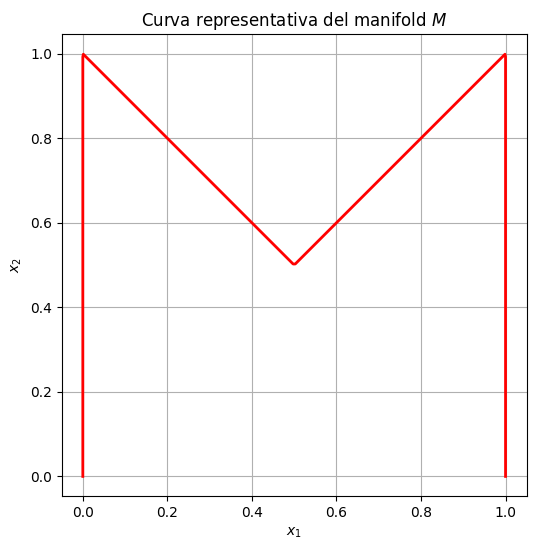

In [ ]:

u_vals = np.linspace(0, 1, 400)
g_vals = np.array([g(u) for u in u_vals])


plt.figure(figsize=(6,6))
plt.plot(g_vals[:,0], g_vals[:,1], 'r', linewidth=2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Curva representativa del manifold $M$")
plt.axis("equal")
plt.grid(True)
plt.show()

## (b) K-means

### (b.1)

El algoritmo de K-means es un algoritmo de clustering para agrupar los datos en K clusters (previamente definidos).

En primer lugar se eligen 4 puntos al azar para ser los centroides iniciales. Luego, se asigna cada punto del conjunto de datos al centroide más cercano (por distancia euclídea). Una vez asignados todos los puntos a un cluster, se calcula la media de cada cluster y ese valor obtenido pasa a ser el nuevo centroide. Esto se repite hasta que los centroides dejen de actualizarse.

En nuestro caso, vamos a trabajar con 4 clusters para que cada uno represente a una recta del manifold.

In [ ]:
class Kmeans:
  # Inicializar atributos y declarar hiperparámetros
  def __init__(self, K):
    self.K = K
    self.centroids = None
    self.labels = None

  # Etapa de entrenamiento
  def fit(self,X):
    n, dx = X.shape
    # centroides random
    index = np.random.choice(n, self.K, replace=False)
    self.centroids = X[index,:]
    # loop hasta converger (nuevos centroides = viejos centroides)
    while True:
      # calculo la distancia de cada punto al centroide mas cercano
      distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
      labels = np.argmin(distances, axis=1)
      new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(self.K)])

      if np.all(self.centroids == new_centroids):
        break
      self.centroids = new_centroids
      self.labels = labels

  # Etapa de testeo:
  def predict(self,X):
    distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)

    return np.argmin(distances, axis=1)


### (b.2)

Se realizó una dispersión de los puntos, representando con un color distinto a cada cluster. Con una cruz roja se marcaron los centroides de los clusters.

In [ ]:
# Entrenar K-Means
K_clusters = 4
kmeans = Kmeans(K_clusters)
kmeans.fit(X)
labels = kmeans.predict(X)

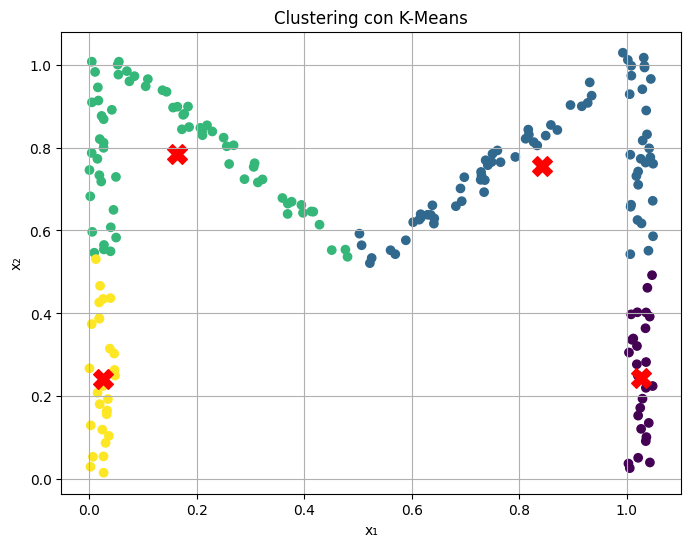

In [ ]:
# Graficar clusters
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', s=200, marker='X')
plt.title('Clustering con K-Means')
plt.grid()
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.show()

### (b.3)

No, el algoritmo K-Means no es suficiente para separar correctamente el manifold en clusters.Esto se debe a que K-Means agrupa los puntos únicamente en función de su proximidad euclídea, asumiendo que cada cluster tiene una forma aproximadamente esférica o circular en el espacio de características.

En este caso, el manifold corresponde a una curva continua. K-Means, al no tener en cuenta la estructura geométrica del manifold, divide los datos por distancia directa a los centroides. Por lo tanto, los clusters obtenidos no representan correctamente las distintas “partes” del manifold, sino regiones separadas por proximidad en el espacio, que pueden cortar la curva arbitrariamente.

## (c) Algoritmo EM

### (c.1)

Podemos modelar los datos como provenientes de una mezcla de gaussianas.
Sea $Z$ una variable latente que indica a qué componente pertenece cada muestra, con:

$$Z\sim\text{Cat}(\{c_1,\dots,c_k\})$$

y dado que los datos $X$ siguen una distribución normal multivariada $X|Z=k\sim\mathcal{N}(\mu_k,\Sigma_k)$

De esta manera, el modelo completo queda determinado por el conjunto de parámetros:

$$\theta=(c_k,\mu_k,\Sigma_k)$$

El objetivo es estimar estos parámetros de manera no supervisada, es decir, sin observar directamente la variable latente $Z$. Para eso, usamos el algoritmo EM (expectation-maximization) que itera entre expectación y maximización.

En la etapa de expectación, se calcula la probabilidad de que cada punto pertenezca a cada cluster usando la pdf de una gaussiana:

$$q(k|x) =\frac{c_k \, |\Sigma_k|^{-\frac{1}{2}} \exp\left(-\frac{1}{2}(x - \mu_k)^{T} \Sigma_k^{-1} (x - \mu_k)\right)}{
\sum_{m=1}^{K}c_m \, |\Sigma_m|^{-\frac{1}{2}}\, \exp\!\left(-\frac{1}{2}(x - \mu_m)^{T} \Sigma_m^{-1} (x - \mu_m)\right)}$$


En la etapa de maximización, se actualizan los parámetros de cada gaussiana en función de las responsabilidades calculadas:

$$c_k=\frac{1}{n}\sum_{i=1}^nq(k|x) \quad \mu_k = \frac{\sum_{i=1}^nq(k|x_i)\cdot x_i}{\sum_{i=1}^nq(k|x_i)}\quad \Sigma_k=\frac{\sum_{i=1}^nq(k|x_i)\cdot(x_i-\mu_k)(x_i-\mu_k)^T}{\sum_{i=1}^nq(k|x_i)}$$

In [ ]:
import numpy as np

class EM:
    @staticmethod
    def _gaussian_pdf(X, mean, cov):
      n, d = X.shape
      det_cov = np.linalg.det(cov)
      inv_cov = np.linalg.inv(cov)
      norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)
      diff = X - mean
      exponent = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
      pdf = norm_const * np.exp(exponent)
      return pdf

    # Inicializar atributos y declarar hiperparámetros.
    def __init__(self, K, max_iter):
        self.K = K
        self.max_iter = max_iter

        # Parámetros del GMM
        self.c_k = None     # Pesos de la mezcla (c_k)
        self.mu_k = None    # Medias de las Gaussianas (μ_k)
        self.Sigma_k = None # Covarianzas de las Gaussianas (Σ_k)

    # Etapa de entrenamiento.
    def fit(self, X):
        N, D = X.shape
        kmeans = Kmeans(self.K)
        kmeans.fit(X)
        self.mu_k  = kmeans.centroids
        labels = kmeans.predict(X)
        self.c_k = np.ones(self.K) / self.K
        self.Sigma_k = np.array([np.cov(X[labels == k], rowvar=False)for k in range(self.K)])

        for i in range(self.max_iter):
            # E-Step
            weighted_pdfs = np.zeros((N, self.K))
            for k in range(self.K):
                pdf = self._gaussian_pdf(X, self.mu_k[k], self.Sigma_k[k])
                weighted_pdfs[:, k] = self.c_k[k] * pdf
            p_x = np.sum(weighted_pdfs, axis=1)
            # Responsabilidades gamma= q(k|x_i)
            gamma = weighted_pdfs / (p_x[:, np.newaxis])
            # M-Step
            N_k = np.sum(gamma, axis=0)

            self.c_k = N_k / N
            self.mu_k = np.dot(gamma.T, X) / (N_k[:, np.newaxis])
            for k in range(self.K):
                diff = X - self.mu_k[k]
                self.Sigma_k[k] = np.dot(gamma[:, k] * diff.T, diff) / (N_k[k])
        return self

    # Etapa de testeo soft
    def predict_proba(self, X):
        N_test = X.shape[0]
        weighted_pdfs = np.zeros((N_test, self.K))
        for k in range(self.K):
            pdf = self._gaussian_pdf(X, self.mu_k[k], self.Sigma_k[k])
            weighted_pdfs[:, k] = self.c_k[k] * pdf
        p_x = np.sum(weighted_pdfs, axis=1)
        gamma = weighted_pdfs / (p_x[:, np.newaxis] + 1e-10)
        return gamma

    # Etapa de testeo hard
    def predict(self, X):
        gamma_ik = self.predict_proba(X)
        return np.argmax(gamma_ik, axis=1)

### (c.2)

En el gráfico de dispersión se asigna un color distinto a cada cluster obtenido mediante el algoritmo EM. Se observa que la separación por clusters mejora sustancialmente con respecto a K-Means.
En este caso, cada cluster logra representar adecuadamente una porción del manifold, siguiendo su forma y dirección.
En este contexto, puede interpretarse que cada cluster aproxima una “recta” o tramo local del manifold, lo que demuestra que EM captura mejor la geometría subyacente de los datos.

In [ ]:
em_model = EM(K=K_clusters, max_iter=200)
em_model.fit(X)
labels = em_model.predict(X)

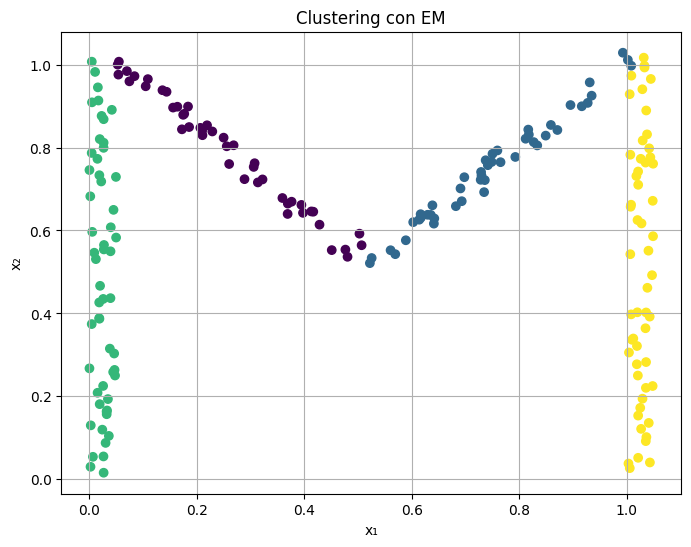

In [ ]:
# Graficar clusters
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Clustering con EM')
plt.grid()
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.show()

### (C.3)

En este gráfico se representan las fronteras de decisión obtenidas mediante el algoritmo EM con $K=4$ componentes gaussianas.
Cada región coloreada corresponde al área del espacio donde la probabilidad de pertenencia a un determinado cluster es mayor.

Se observa que las fronteras no son lineales, sino que presentan formas suavizadas y adaptativas, reflejando que el modelo utiliza matrices de covarianza completas para definir el contorno de cada cluster.


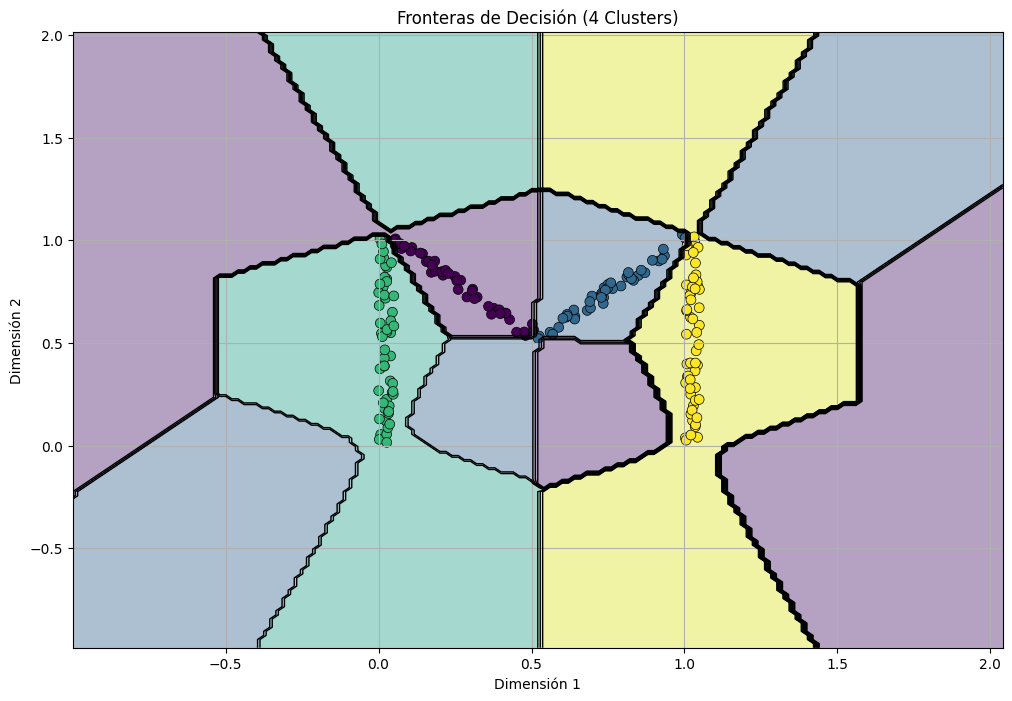

In [ ]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
step = 0.02

xx, yy = np.meshgrid(np.arange(x_min, x_max, step),np.arange(y_min, y_max, step))
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = em_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12, 8))
cmap_clusters = plt.colormaps.get_cmap('viridis')

plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_clusters)
plt.contour(xx, yy, Z, colors='k', linewidths=1.0)
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap=cmap_clusters, edgecolor='black', linewidth=0.5)

plt.title(f'Fronteras de Decisión ({K_clusters} Clusters)')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.grid()

## (d) PCA

### (d.1)

El objetivo del Análisis de Componentes Principales (PCA) es reducir la dimensionalidad de los datos preservando la mayor cantidad posible de su varianza.
Para ello, el método busca un nuevo sistema de coordenadas formado por autovectores de la matriz de covarianza de los datos, donde cada eje (componente principal) explica una fracción decreciente de la varianza total.

In [ ]:
class PCA:
  # Inicializar atributos y declarar hiperparámetros. No aclarar aún la dimensión
  # del espacio latente
  def __init__(self,):
    self.k = None
    self.eigenvalues = None
    self.components = None
    self.mean = None

  # Etapa de entrenamiento. Se entrenan todos los autovectores, sin definir la
  # dimensión latente
  def fit(self,X):
    self.mean = np.mean(X, axis=0)
    X_centered = X - self.mean

    cov = np.cov(X_centered.T)
    eigvals, eigenvectors = np.linalg.eig(cov)
    idx = np.argsort(eigvals)[::-1]
    self.eigenvalues = eigvals[idx]
    self.components = eigenvectors[:, idx]

  # Transformar del espacio original al espacio latente de dimensión k.
  def transform(self,X,k):
    X_centered = X - self.mean
    return X_centered @ self.components[:, :k]

  # Transformar del espacio latente al espacio original
  def inverse_transform(self,U):
    return U @ self.components[:, :U.shape[1]].T + self.mean

  # fit + transform
  def fit_transform(self,X,k):
    self.fit(X)
    return self.transform(X,k)

### (d.2)

Se separan los clusters según el algoritmo EM y se entrena un PCA para cada cluster

In [ ]:
pca_models = {}
pca_results = {}

for k in range(K_clusters):
    X_k = X[labels == k]
    pca = PCA()
    pca.fit(X_k)
    pca_models[k] = pca

### (d.3)


Se indican los valores mínimos y máximos de proyección para cada cluster.

In [ ]:
print("Valores Mínimos y Máximos de la Proyección\n")
projection_ranges = {}
for k in range(K_clusters):
    pca = pca_models[k]
    projection = pca.transform(X[labels == k], k=1).flatten()
    min_val = np.min(projection)
    max_val = np.max(projection)
    projection_ranges[k] = {'Min': min_val, 'Max': max_val}

    print(f"Cluster {k}:")
    print(f"Mínimo: {min_val:.4f}")
    print(f"Máximo: {max_val:.4f}\n")

Valores Mínimos y Máximos de la Proyección

Cluster 0:
Mínimo: -0.2979
Máximo: 0.3360

Cluster 1:
Mínimo: -0.3705
Máximo: 0.3211

Cluster 2:
Mínimo: -0.5228
Máximo: 0.4685

Cluster 3:
Mínimo: -0.5037
Máximo: 0.4862



### (d.4)

Se utiliza el método *inverse_transform()* de PCA para reconstruir el manifold en el espacio original a partir de los valores extremos proyectados en el espacio latente de cada cluster.
Para esto, se toma el rango de proyección (u_min, u_max) asociado a cada PCA y se genera una línea de puntos en el espacio reducido, que luego se mapea nuevamente al espacio original.
El resultado de esta reconstrucción es una recta que representa el subespacio lineal aprendido por el PCA en cada cluster.

En el primer gráfico se muestran los puntos del dataset coloreados según su pertenencia a cada cluster y, sobre ellos, las rectas reconstruidas correspondientes a cada modelo local de PCA. Esto permite visualizar claramente cómo cada PCA se ajusta a una región del manifold, capturando su orientación y tendencia local.

En el segundo gráfico se superpone el manifold original con el manifold reconstruido a partir de los PCA locales.
La comparación entre ambas curvas permite evaluar la calidad de la aproximación: cuando las rectas reconstruidas se alinean con la forma del manifold original. Se concluye que la combinación del algoritmo EM y los PCA locales logra representar fielmente la estructura global no lineal mediante modelos lineales locales.

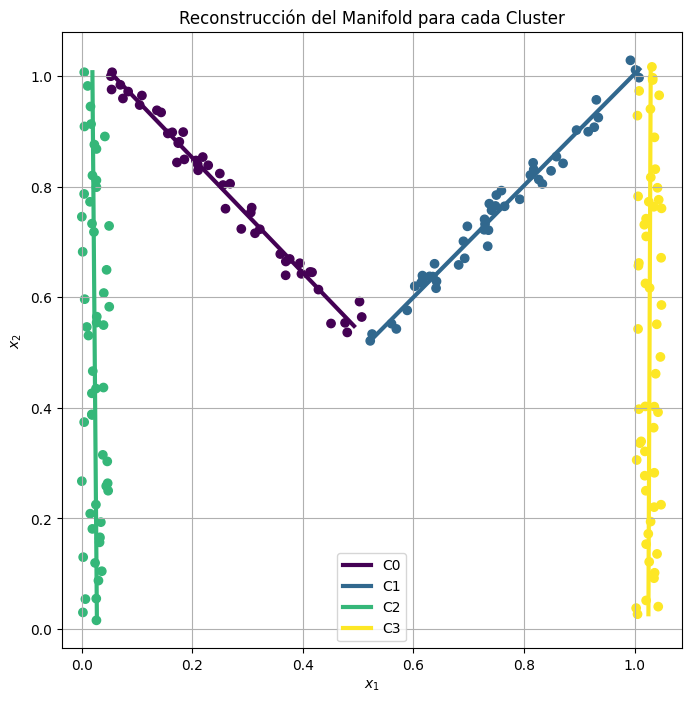

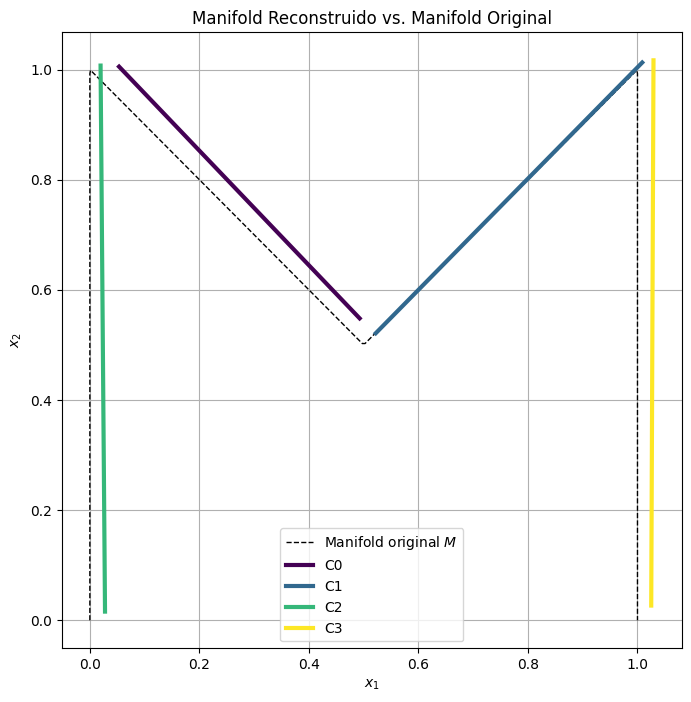

In [ ]:

cmap_lines = plt.colormaps['viridis']
colors = cmap_lines(np.linspace(0, 1, K_clusters))

#grafico los puntos
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap=cmap_lines)
plt.title('Reconstrucción del Manifold para cada Cluster')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.axis('equal')
plt.grid()

# Grafico el Manifold Local para cada Cluster
for k in range(K_clusters):
    pca = pca_models[k]
    pr = projection_ranges[k]

    u_min = pr['Min']
    u_max = pr['Max']
    U_line = np.linspace(u_min, u_max, 100).reshape(-1, 1)
    X_reconstructed = pca.inverse_transform(U_line)
    # grafico la recta
    plt.plot(X_reconstructed[:, 0], X_reconstructed[:, 1], color=colors[k],linewidth=3,label=f'C{k}')

plt.legend()
plt.show()

#Grafico manifold original vs reconstruido

u_vals = np.linspace(0, 1, 400)
g_vals = np.array([g(u) for u in u_vals])

plt.figure(figsize=(8, 8))
plt.plot(g_vals[:,0], g_vals[:,1], 'k--', linewidth=1, label='Manifold original $M$')

for k in range(K_clusters):
    pca = pca_models[k]
    pr = projection_ranges[k]
    u_min = pr['Min']
    u_max = pr['Max']
    U_line = np.linspace(u_min, u_max, 100).reshape(-1, 1)
    X_reconstructed = pca.inverse_transform(U_line)
    plt.plot(X_reconstructed[:, 0], X_reconstructed[:, 1],color=colors[k],linewidth=3,label=f'C{k}')

plt.title('Manifold Reconstruido vs. Manifold Original')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)
plt.show()

## (e) Detector de Anomalías

### (e.1)

Se define una grilla uniforme de puntos en el dominio $[0,1]\times[0,1]$, con el objetivo de evaluar cómo responden los modelos entrenados (EM y PCA locales) ante nuevas observaciones en distintas regiones del espacio.
Cada punto de la grilla se asigna al cluster correspondiente utilizando el modelo EM previamente entrenado, lo que permite identificar qué modelo local de PCA será responsable de su reconstrucción.

Posteriormente, para cada cluster, se toma el conjunto de puntos de la grilla que fueron clasificados como pertenecientes a dicho cluster.
Cada punto $x_i$ se proyecta al espacio latente mediante el modelo PCA local asociado:

$$u_i=\text{PCAk.transform}(x_i)$$

y luego se reconstruye al espacio original mediante:

$$\hat{x_i}=\text{PCAk.inverse_transform}(u_i)$$

A partir de esta reconstrucción se calcula el error cuadrático de reconstrucción para cada punto:

$$E_i=||x_i-\hat{x_i}||^2$$

Finalmente, se define un umbral de error thr=0.005 y se clasifica cada punto de la grilla como anómalo si su error de reconstrucción supera dicho valor:

$$E_i>thr$$

De esta manera, se obtiene un mapa de anomalías que refleja las regiones del espacio donde los modelos locales de PCA no logran representar adecuadamente los datos.
En términos geométricos, los puntos con bajo error se encuentran próximos al manifold aprendido, mientras que los puntos clasificados como anómalos se ubican alejados de las regiones donde los PCA locales fueron entrenados, es decir, fuera de la estructura subyacente de los datos originales.

In [ ]:
x_coords = np.linspace(0, 1, 100)
y_coords = np.linspace(0, 1, 100)
xx, yy = np.meshgrid(x_coords, y_coords)
grid_points = np.c_[xx.ravel(), yy.ravel()]

thr = 0.005

# primero asumo que todos los puntos son anomalias
anomaly_mask = np.ones(len(grid_points), dtype=bool)
labels_grid = em_model.predict(grid_points)

for k in range(K_clusters):
    pca = pca_models[k]
    k_indices = np.where(labels_grid == k)[0]
    X_k_grid = grid_points[k_indices]

    U_k_grid = pca.transform(X_k_grid, k=1)
    X_k_reconstructed = pca.inverse_transform(U_k_grid)
    reconstruction_error = np.sum((X_k_grid - X_k_reconstructed)**2, axis=1)
    anomaly_k = reconstruction_error >= thr
    anomaly_mask[k_indices] = anomaly_k

### (e.2)

Se grafican los puntos no anómalos identificados por el detector, y se observa que el desempeño no es satisfactorio, ya que el modelo clasifica como no anómalos varios puntos que en realidad sí lo son.
Estos puntos erróneamente aceptados se encuentran principalmente a lo largo de las diagonales del espacio, lo que indica que el algoritmo no logra discriminar correctamente los límites del manifold y presenta falsos negativos en esas regiones.

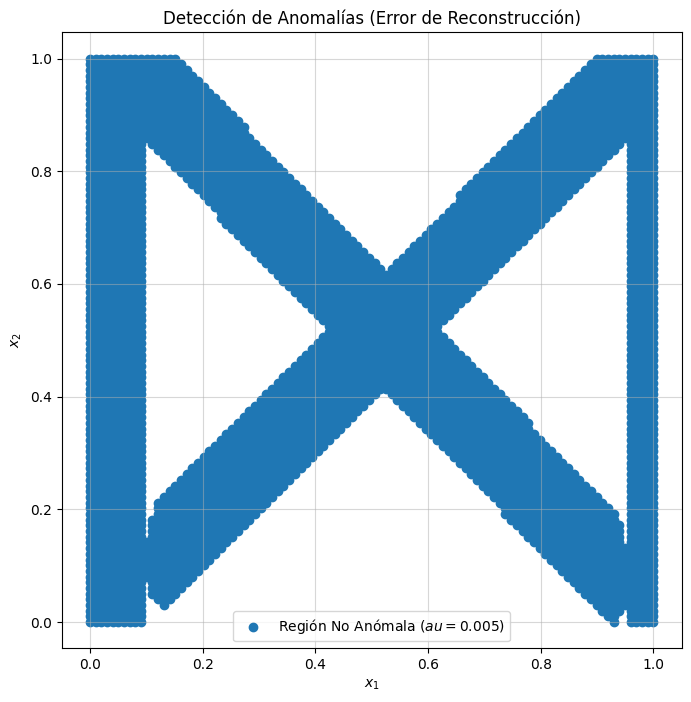

In [ ]:
# 3. Graficar puntos NO anómalos
non_anomaly_points = grid_points[~anomaly_mask]

plt.figure(figsize=(8, 8))
plt.scatter(non_anomaly_points[:, 0], non_anomaly_points[:, 1], label=f'Región No Anómala ($\tau={thr}$)')
plt.title('Detección de Anomalías (Error de Reconstrucción)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

### (e.3)

A diferencia del método anterior, donde se consideraba únicamente el error cuadrático de reconstrucción, en este caso se agrega una segunda condición:
un punto de la grilla es considerado no anómalo solo si cumple simultáneamente:


*   Presenta un error de reconstrucción menor que el umbral establecido ($E_i< thr$)
*   Su proyección sobre la componente principal se encuentra dentro del rango
$[u_{min},u_{max}]$ del cluster correspondiente.

Los puntos que no satisfacen alguna de estas dos condiciones se marcan como anómalos.
Finalmente, se grafican únicamente los puntos no anómalos, representando la región del espacio donde los modelos PCA locales reconstruyen correctamente los datos y donde la proyección se encuentra dentro del rango observado durante el entrenamiento.

Esta estrategia mejora la detección de anomalías, ya que evita clasificar como válidos aquellos puntos que, aunque presentan bajo error de reconstrucción, se proyectan fuera del rango natural del manifold.
El resultado es una región más precisa, que delimita de manera efectiva las zonas del espacio consistentes con la estructura aprendida por los modelos EM–PCA.

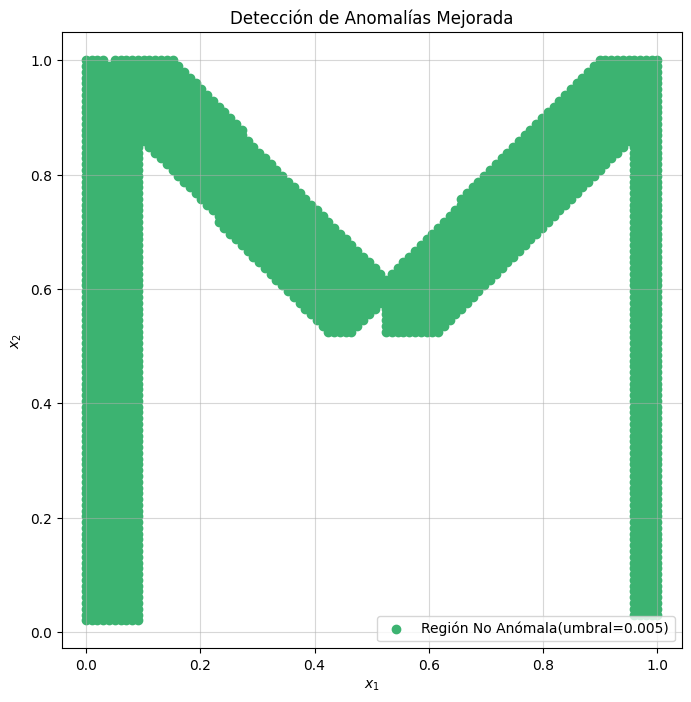

In [ ]:
anomaly_mask_2 = np.ones(len(grid_points), dtype=bool)
labels_grid = em_model.predict(grid_points)

# Iterar sobre cada cluster
for k in range(K_clusters):
    pca = pca_models.get(k)
    pr = projection_ranges.get(k)
    k_indices = np.where(labels_grid == k)[0]
    X_k_grid = grid_points[k_indices]
    U_k_grid = pca.transform(X_k_grid, k=1).flatten()
    X_k_reconstructed = pca.inverse_transform(U_k_grid.reshape(-1, 1))
    reconstruction_error = np.sum((X_k_grid - X_k_reconstructed)**2, axis=1)

    low_error = reconstruction_error < thr
    u_min = pr['Min']
    u_max = pr['Max']
    within_range = (U_k_grid >= u_min) & (U_k_grid <= u_max)

    # Un punto es NO anómalo si cumple AMBAS condiciones
    non_anomaly_k = low_error & within_range
    anomaly_mask_2[k_indices] = ~non_anomaly_k

# Grafico puntos NO anómalos
non_anomaly_points_2 = grid_points[~anomaly_mask_2]

plt.figure(figsize=(8, 8))
plt.scatter(non_anomaly_points_2[:, 0], non_anomaly_points_2[:, 1],
            c='mediumseagreen', label=f'Región No Anómala(umbral={thr})')
plt.title('Detección de Anomalías Mejorada')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()